In [10]:
import numpy as np
import matplotlib.pyplot as plt
import plot_scripts as plts
import os
plt.style.use("mplstyle")

In [81]:
def FGname(inp_signal):
    if (inp_signal == '21cm'):
        FG = 'None'
        dataname = '21cm'
    elif (inp_signal == 'FG+21cm'):
        FG = 'Smooth'
        dataname = 'FG'
    elif (inp_signal == 'FG+MM+21cm'):
        FG = 'Unsmooth'
        dataname = 'FGMM'
    return FG, dataname

inp_signal = 21cm, flag = PERIODIC, scf = None
inp_signal = 21cm, flag = PERIODIC+RANDOM, scf = None
inp_signal = 21cm, flag = RANDOM, scf = None
Saved: plots/fft_allflags.pdf


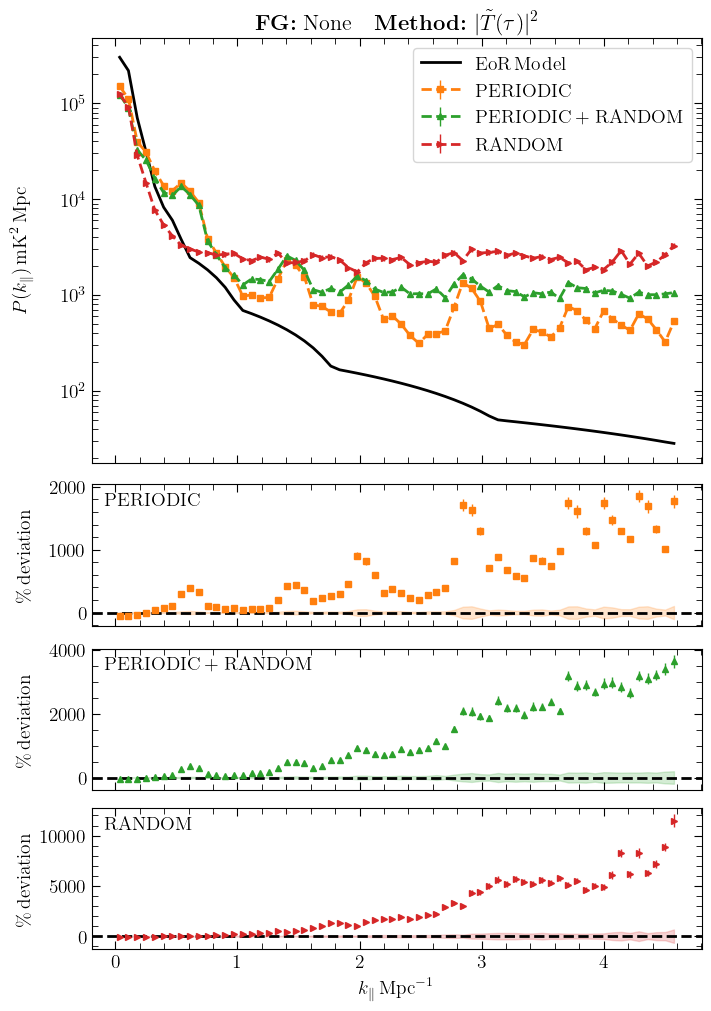

In [82]:
# --------------------------------------------------
path       = "results"
inp_signal = "21cm"
SCF        = "None"

modes  = ['PERIODIC', 'PERIODIC+RANDOM', 'RANDOM']
colors = ['C1', 'C2', 'C3']
fmts = ['s', '^', '>']

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, None


figname = f"plots/fft_allflags.pdf"
os.makedirs("plots", exist_ok=True)


# --------------------------------------------------
fig = plt.figure(figsize=(7, 10))
gs  = fig.add_gridspec(
    4, 1,
    height_ratios=[3, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 4)]


# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/fft_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        label=fr"$\rm{{ {mode} }}$"
    )

    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    # if band:
    axd[i].fill_between(kb_fft, -err_r, err_r,
                        color=color, alpha=0.2,
                        label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    # axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)


# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}$')
# ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)


axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

ax1.set_title(
    r"\rm{  {\bf FG:}~}" + fr"$\mathrm{{   {FG}   }}$"
    + r"\rm{\quad {\bf Method:}~}" + r'$|\tilde{T}(\tau)|^2$'
    # + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


inp_signal = 21cm, flag = PERIODIC, scf = None
inp_signal = 21cm, flag = PERIODIC+RANDOM, scf = None
inp_signal = 21cm, flag = RANDOM, scf = None
Saved: plots/21cm_SCF_None_allflags.pdf


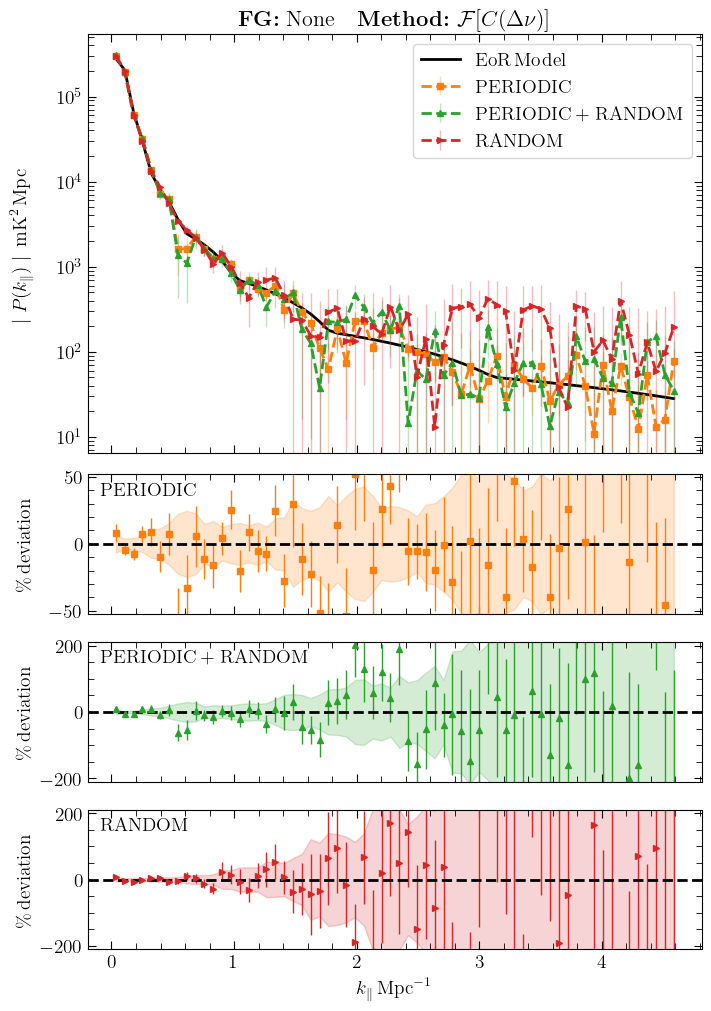

In [83]:
FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210

figname = f"plots/{inp_signal}_SCF_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)


# --------------------------------------------------
fig = plt.figure(figsize=(7, 10))
gs  = fig.add_gridspec(
    4, 1,
    height_ratios=[3, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 4)]


# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$\rm{{ {mode} }}$"
    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    axd[i].fill_between(kb_fft, -err_r, err_r,
                        color=color, alpha=0.2,
                        label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    # axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')
    # axd[i].set_xscale('log')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)
    axd[0].set_ylim(-52, 52)


    
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$\mid P(k_\parallel) \mid \,{\rm mK}^2\,{\rm Mpc}$')
# ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)


axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

ax1.set_title(
    r"\rm{  {\bf FG:}~}" + fr"$\mathrm{{   {FG}   }} $"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    # + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


# zoomed

inp_signal = 21cm, flag = PERIODIC, scf = None
inp_signal = 21cm, flag = PERIODIC+RANDOM, scf = None
inp_signal = 21cm, flag = RANDOM, scf = None
Saved: plots/21cm_SCF_None_allflags.pdf


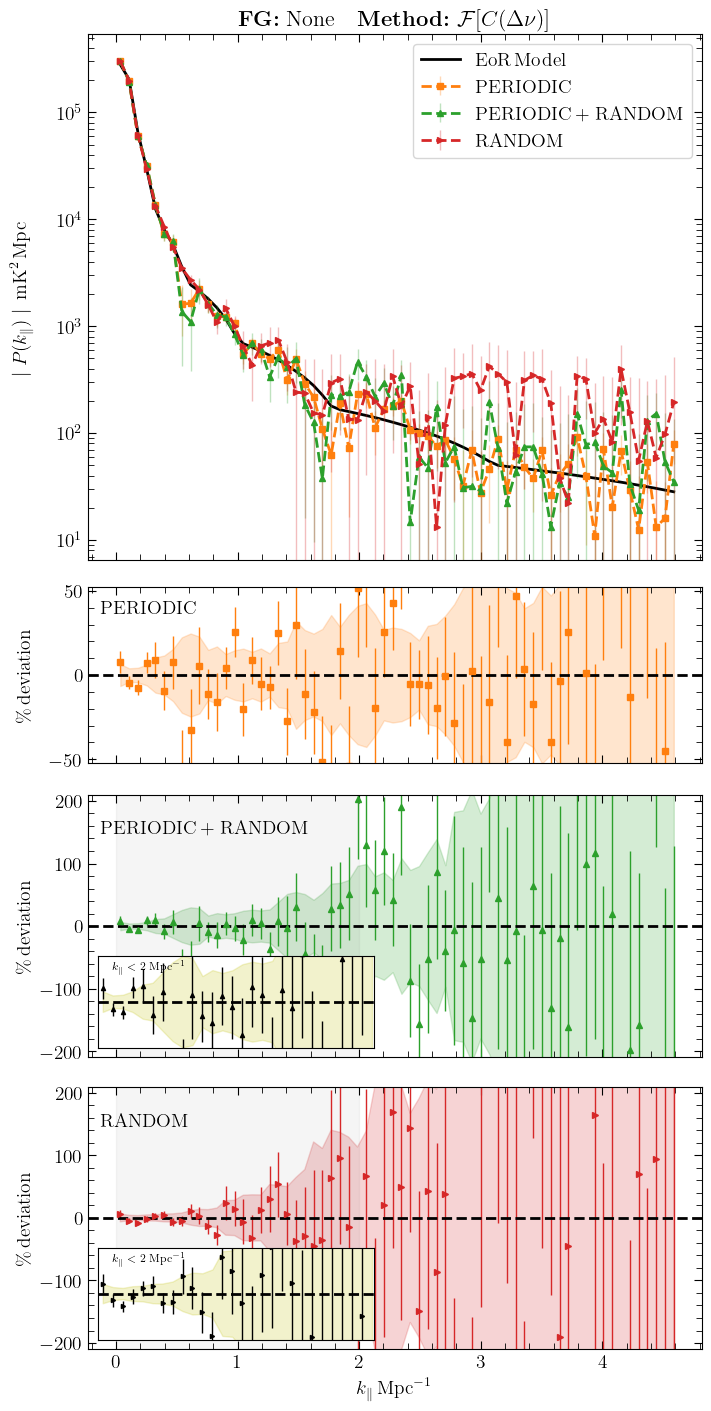

In [86]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210

figname = f"plots/{inp_signal}_SCF_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
fig = plt.figure(figsize=(7, 14))
gs  = fig.add_gridspec(
    4, 1,
    height_ratios=[3, 1, 1.5, 1.5],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 4)]

# --------------------------------------------------
# INSET SETUP
# --------------------------------------------------
kmax_zoom = 2

insets = {}
for idx in [1, 2]:   # <-- last two panels here
    insets[idx] = inset_axes(
        axd[idx],
        width="45%",
        height="35%",
        loc="lower left",
        borderpad=0.5
    )

# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    mask = kb_fft <= kmax_zoom

    # ---------- TOP PANEL ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),
        label=fr"$\rm{{ {mode} }}$"
    )

    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    axd[i].fill_between(
        kb_fft, -err_r, err_r,
        color=color, alpha=0.2,
        label="_nolegend_"
    )

    axd[i].axhline(0, color='k', ls='--')
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)

    axd[0].set_ylim(-52, 52)

    # ---------- INSET (ONLY last two panels) ----------
    if i in [1, 2]:

        # highlight region
        axd[i].axvspan(0, 2, color='gray', alpha=0.08)

        axins = insets[i]

        axins.errorbar(
            kb_fft[mask],
            ratio[mask],
            err_r[mask],
            ms=3,
            elinewidth=1,
            fmt=fmt,
            color='k'
        )

        axins.fill_between(
            kb_fft[mask],
            -err_r[mask],
            err_r[mask],
            color='y',
            alpha=0.2
        )

        axins.axhline(0, color='k', ls='--')

        axins.set_xlim(0, 2)
        axins.set_ylim(-30, 30)

        axins.set_xticks([])
        axins.set_yticks([])

        for spine in axins.spines.values():
            spine.set_linewidth(0.8)

        axins.text(
            0.05, 0.85,
            r'$k_\parallel < 2~{\rm Mpc}^{-1}$',
            transform=axins.transAxes,
            fontsize=8
        )

# --------------------------------------------------
# FORMATTING
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$\mid P(k_\parallel) \mid \,{\rm mK}^2\,{\rm Mpc}$')
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)
axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

ax1.set_title(
    r"\rm{  {\bf FG:}~}" + fr"$\mathrm{{   {FG}   }} $"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')

print("Saved:", figname)

<>:71: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:71: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_3850/3330262619.py:71: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  inp_title = "FG\ (smooth)"


inp_signal = FG+21cm, flag = NOFLAG, scf = None
inp_signal = FG+21cm, flag = PERIODIC, scf = None
inp_signal = FG+21cm, flag = PERIODIC+RANDOM, scf = None
inp_signal = FG+21cm, flag = RANDOM, scf = None
Saved: plots/FG_SCF_None_allflags.pdf


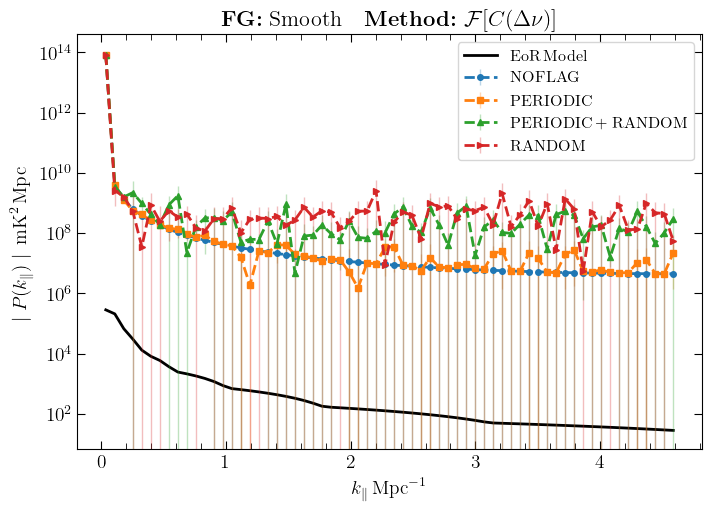

In [17]:
inp_signal = "FG+21cm"
SCF        = "None"

modes  = ['NOFLAG', 'PERIODIC', 'PERIODIC+RANDOM', 'RANDOM']
colors = ['C0', 'C1', 'C2', 'C3']
fmts = ['o', 's', '^', '>']

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, None
    
figname = f"plots/{dataname}_SCF_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)


# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(7, 5))


# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    print(
        f"inp_signal = {data['inp_signal'].tolist()}, "
        f"flag = {data['flag'].tolist()}, "
        f"scf = {data['SCF'].tolist()}"
    )

    # ---------- Power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$\rm{{ {mode} }}$"
    )

    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

# --------------------------------------------------
# FINAL FORMATTING
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$\mid P(k_\parallel)\mid \,{\rm mK}^2\,{\rm Mpc}$')
ax1.set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

# ax1.grid(alpha=0.3)
ax1.legend(fontsize='small')

if(inp_signal == "FG+21cm"):
    inp_title = "FG\ (smooth)"

ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"$\mathrm{{ {FG} }}$"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F}[C(\Delta\nu)] }$'
    # + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$"
)

fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


inp_signal = FG+21cm, flag = NOFLAG, scf = Hann
inp_signal = FG+21cm, flag = PERIODIC, scf = Hann
inp_signal = FG+21cm, flag = PERIODIC+RANDOM, scf = Hann
inp_signal = FG+21cm, flag = RANDOM, scf = Hann
Saved: plots/FG_Hann_allflags.pdf


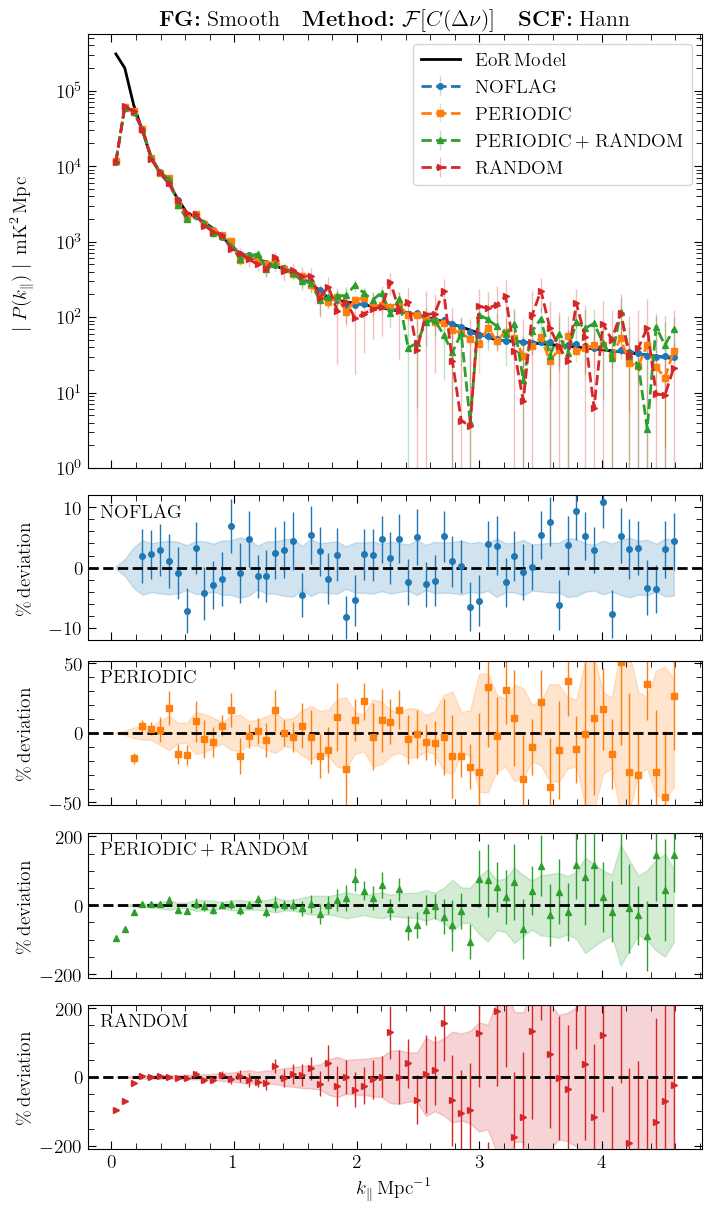

In [21]:
inp_signal = "FG+21cm"
SCF        = "Hann"

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210


    
figname = f"plots/{dataname}_{SCF}_allflags.pdf"

# --------------------------------------------------
fig = plt.figure(figsize=(7, 12))
gs  = fig.add_gridspec(
    5, 1,
    height_ratios=[3, 1, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 5)]

# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$\rm{{ {mode} }}$"
    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )
    
    axd[i].fill_between(kb_fft, -err_r, err_r,
                        color=color, alpha=0.2,
                        label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    # axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)
    axd[0].set_ylim(-12, 12)
    axd[1].set_ylim(-52, 52)

# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$\mid P(k_\parallel) \mid \,{\rm mK}^2\,{\rm Mpc}$')
# ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)


axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

    
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"$\mathrm{{{FG}}}$"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


# with zoom

inp_signal = FG+21cm, flag = NOFLAG, scf = Hann
inp_signal = FG+21cm, flag = PERIODIC, scf = Hann
inp_signal = FG+21cm, flag = PERIODIC+RANDOM, scf = Hann
inp_signal = FG+21cm, flag = RANDOM, scf = Hann
Saved: plots/FG_Hann_allflags.pdf


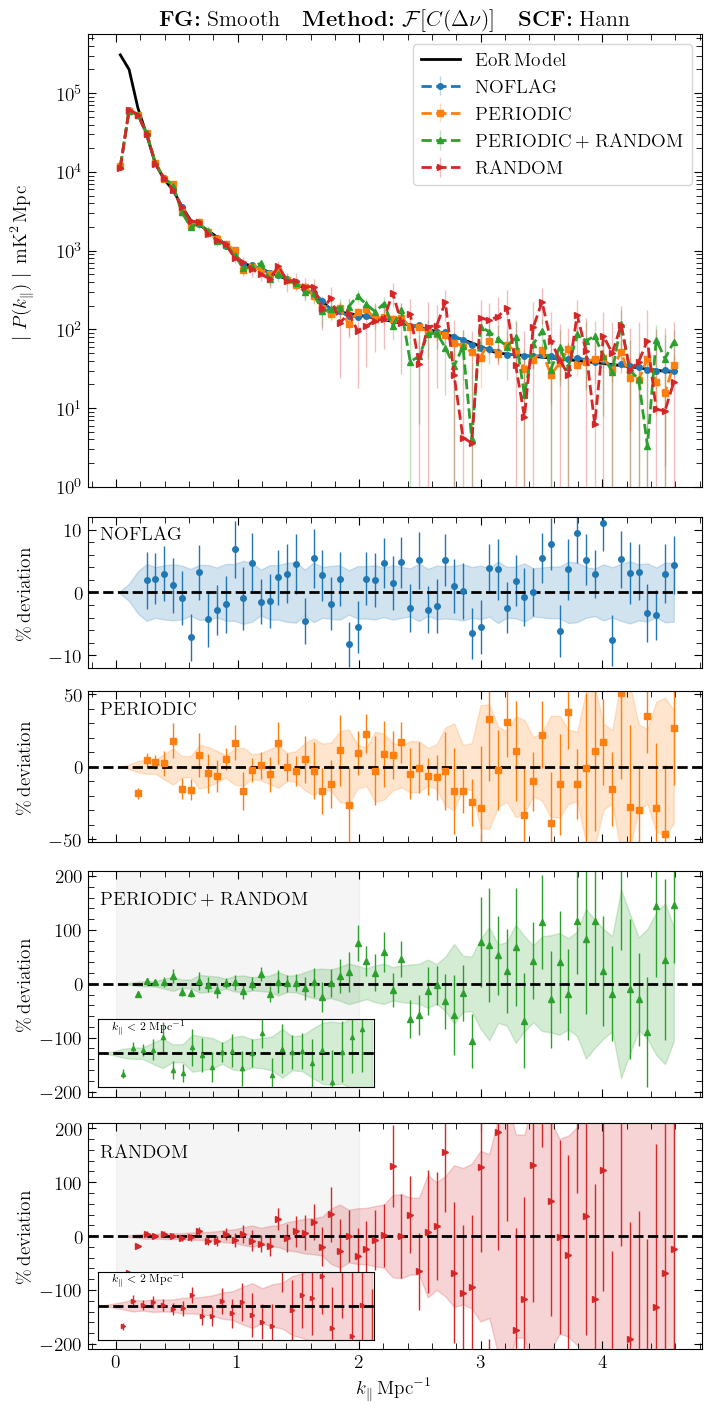

In [77]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

inp_signal = "FG+21cm"
SCF        = "Hann"

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210

figname = f"plots/{dataname}_{SCF}_allflags.pdf"

# --------------------------------------------------
fig = plt.figure(figsize=(7, 14))
gs  = fig.add_gridspec(
    5, 1,
    height_ratios=[3, 1, 1, 1.5, 1.5],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 5)]

kmax_zoom = 2

# Prepare inset axes ONLY for last two panels
insets = {}
for idx in [2, 3]:
    insets[idx] = inset_axes(
        axd[idx],
        width="45%",
        height="30%",
        loc="lower left",
        borderpad=0.5
    )

# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    mask = kb_fft <= kmax_zoom

    # ---------- TOP PANEL ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),
        label=fr"$\rm{{ {mode} }}$"
    )

    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )
    
    axd[i].fill_between(
        kb_fft, -err_r, err_r,
        color=color, alpha=0.2
    )

    axd[i].axhline(0, color='k', ls='--')
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)

    axd[0].set_ylim(-12, 12)
    axd[1].set_ylim(-52, 52)

    # ---------- INSET (ONLY for last two panels) ----------
    if i in [2, 3]:

        axd[i].axvspan(0, 2, color='gray', alpha=0.08)
        axins = insets[i]

        axins.errorbar(
            kb_fft[mask],
            ratio[mask],
            err_r[mask],
            ms=3,
            elinewidth=1,
            fmt=fmt,
            color=color
        )

        axins.fill_between(
            kb_fft[mask],
            -err_r[mask],
            err_r[mask],
            color=color,
            alpha=0.2
        )

        axins.axhline(0, color='k', ls='--')

        axins.set_xlim(0., 2)
        axins.set_ylim(-30, 30)   # <-- tighten for visibility

        axins.set_xticks([])
        axins.set_yticks([])
        # axins.set_xticklabels([])
        # axins.set_yticklabels([])
        
        for spine in axins.spines.values():
            spine.set_linewidth(0.8)

        axins.text(
            0.05, 0.85,
            r'$k_\parallel < 2~{\rm Mpc}^{-1}$',
            transform=axins.transAxes,
            fontsize=8
        )

# --------------------------------------------------
# FORMATTING
ax1.set_yscale('log')
ax1.set_ylabel(r'$\mid P(k_\parallel) \mid \,{\rm mK}^2\,{\rm Mpc}$')
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"$\mathrm{{{FG}}}$"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')

print("Saved:", figname)

inp_signal = FG+MM+21cm, flag = NOFLAG, scf = Hann
inp_signal = FG+MM+21cm, flag = PERIODIC, scf = Hann
inp_signal = FG+MM+21cm, flag = PERIODIC+RANDOM, scf = Hann
inp_signal = FG+MM+21cm, flag = RANDOM, scf = Hann
Saved: plots/FGMM_Hann_allflags.pdf


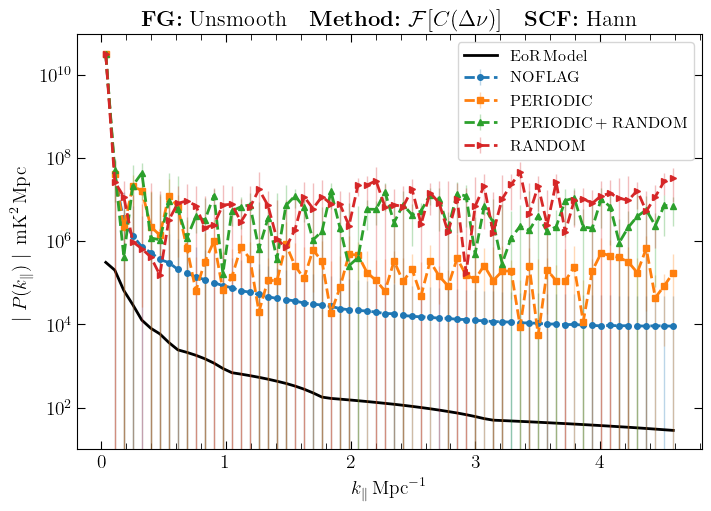

In [19]:
inp_signal = "FG+MM+21cm"
SCF        = "Hann"

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, None


figname = f"plots/{dataname}_{SCF}_allflags.pdf"

os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(7, 5))


# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    print(
        f"inp_signal = {data['inp_signal'].tolist()}, "
        f"flag = {data['flag'].tolist()}, "
        f"scf = {data['SCF'].tolist()}"
    )

    # ---------- Power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$\rm{{ {mode} }}$"
    )

    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )
    axd[0].set_ylim(-12, 12)
    axd[1].set_ylim(-52, 52)

# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$\mid P(k_\parallel) \mid \,{\rm mK}^2\,{\rm Mpc}$')
ax1.set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

# ax1.grid(alpha=0.3)
ax1.legend(fontsize='small')

   
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"\rm{{{FG}}}"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F}[C(\Delta\nu)] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$"
)

fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = PERIODIC, scf = GP
inp_signal = FG+MM+21cm, flag = PERIODIC+RANDOM, scf = GP
inp_signal = FG+MM+21cm, flag = RANDOM, scf = GP
Saved: plots/FGMM_GP_allflags.pdf


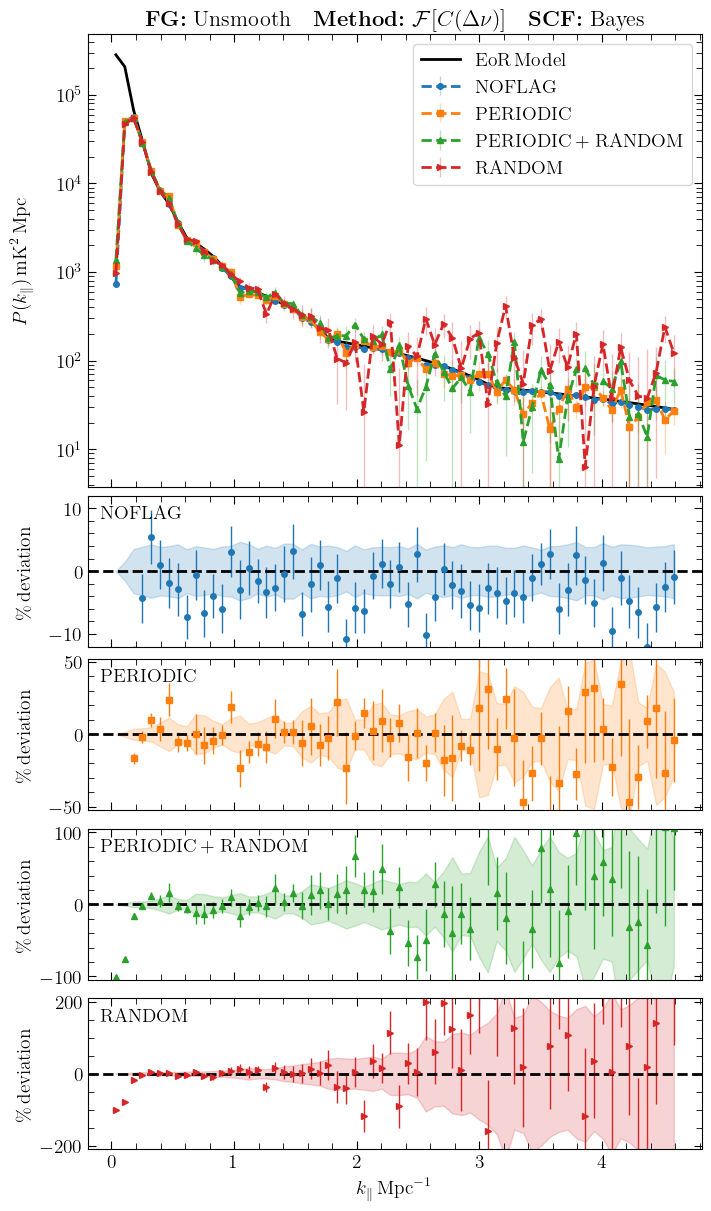

In [20]:
inp_signal = "FG+MM+21cm"
SCF        = "GP"

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210
 
figname = f"plots/{dataname}_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 12))
gs  = fig.add_gridspec(
    5, 1,
    height_ratios=[3, 1, 1, 1, 1],
    hspace=0.02
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 5)]

# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$\rm{{ {mode} }}$" 

    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    axd[i].fill_between(kb_fft, -err_r, err_r,
                        color=color, alpha=0.2,
                        label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    # axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)
    axd[0].set_ylim(-12, 12)
    axd[1].set_ylim(-52, 52)
    axd[2].set_ylim(-105, 105)

    
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}$')
# ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)


axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

SCF = 'Bayes'
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"\rm{{{FG}}}"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = PERIODIC, scf = GP
inp_signal = FG+MM+21cm, flag = PERIODIC+RANDOM, scf = GP
inp_signal = FG+MM+21cm, flag = RANDOM, scf = GP
Saved: plots/FGMM_GP_allflags.pdf


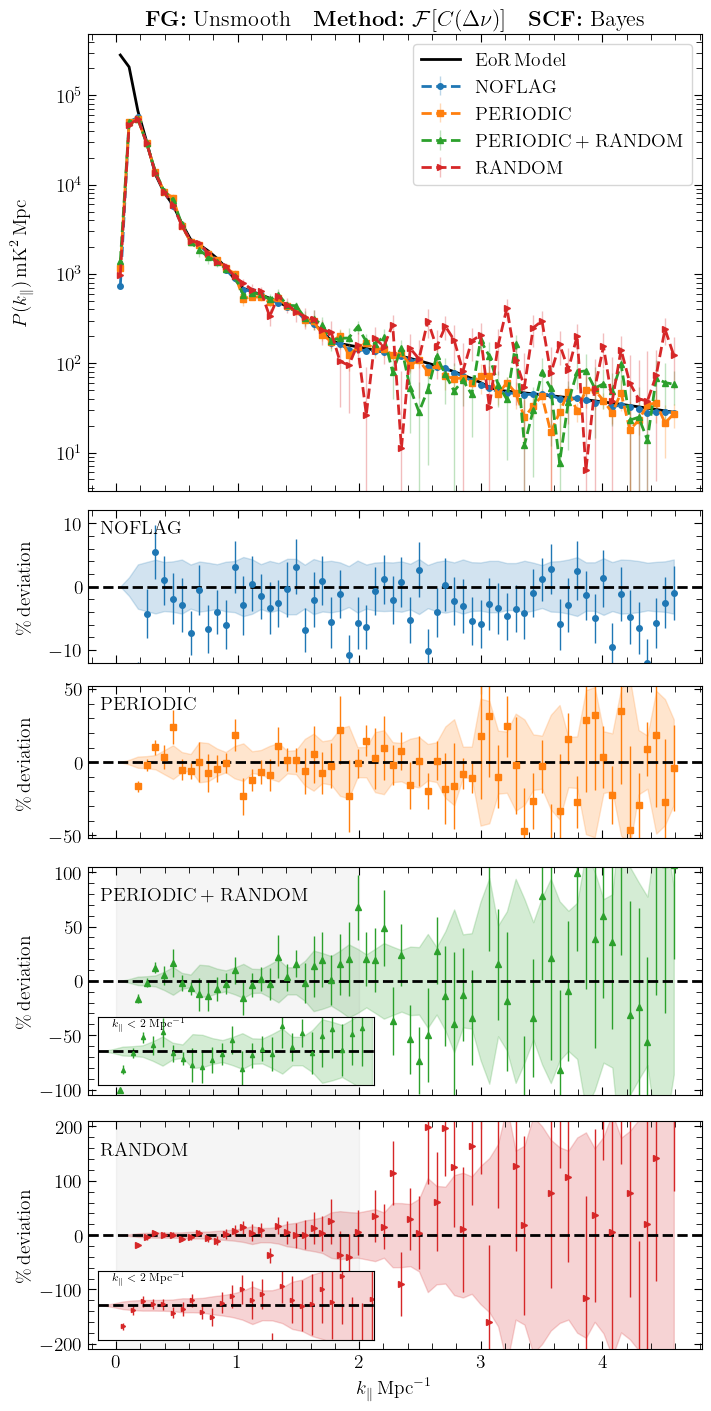

In [79]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

inp_signal = "FG+MM+21cm"
SCF        = "GP"

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210
 
figname = f"plots/{dataname}_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 14))
gs  = fig.add_gridspec(
    5, 1,
    height_ratios=[3, 1, 1, 1.5, 1.5],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 5)]

# --------------------------------------------------
# INSET SETUP
# --------------------------------------------------
kmax_zoom = 2

insets = {}
for idx in [2, 3]:
    insets[idx] = inset_axes(
        axd[idx],
        width="45%",
        height="30%",
        loc="lower left",
        borderpad=0.5
    )

# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    mask = kb_fft <= kmax_zoom

    # ---------- TOP PANEL ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),
        label=fr"$\rm{{ {mode} }}$"
    )

    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    axd[i].fill_between(
        kb_fft, -err_r, err_r,
        color=color, alpha=0.2,
        label="_nolegend_"
    )

    axd[i].axhline(0, color='k', ls='--')
    axd[i].set_ylabel(r'\rm{\%\,deviation}')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)

    axd[0].set_ylim(-12, 12)
    axd[1].set_ylim(-52, 52)
    axd[2].set_ylim(-105, 105)

    # ---------- INSET (ONLY for last two panels) ----------
    if i in [2, 3]:

        # shaded region
        axd[i].axvspan(0, 2, color='gray', alpha=0.08)

        axins = insets[i]

        axins.errorbar(
            kb_fft[mask],
            ratio[mask],
            err_r[mask],
            ms=3,
            elinewidth=1,
            fmt=fmt,
            color=color
        )

        axins.fill_between(
            kb_fft[mask],
            -err_r[mask],
            err_r[mask],
            color=color,
            alpha=0.2
        )

        axins.axhline(0, color='k', ls='--')

        axins.set_xlim(0, 2)
        axins.set_ylim(-30, 30)

        axins.set_xticks([])
        axins.set_yticks([])

        for spine in axins.spines.values():
            spine.set_linewidth(0.8)

        axins.text(
            0.05, 0.85,
            r'$k_\parallel < 2~{\rm Mpc}^{-1}$',
            transform=axins.transAxes,
            fontsize=8
        )

# --------------------------------------------------
# FORMATTING
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}$')
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)
axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

SCF = 'Bayes'
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"\rm{{{FG}}}"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')

print("Saved:", figname)